

# SaaS Customer Churn Prediction

## Business Problem

Customer churn is one of the most important challenges faced by subscription-based businesses. Acquiring a new customer is significantly more expensive than retaining an existing one.

The objective of this project is to build a machine learning model that predicts whether a customer is likely to churn based on demographic information, service usage, subscription details, and account characteristics.

## Project Goals

- Analyze customer churn behavior
- Identify factors contributing to churn
- Build a predictive machine learning model
- Generate actionable business recommendations




Import Libraries

In [32]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings('ignore')

Load Dataset

In [33]:
df = pd.read_excel("Telco_customer_churn.xlsx")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [5]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


Churn Distribution

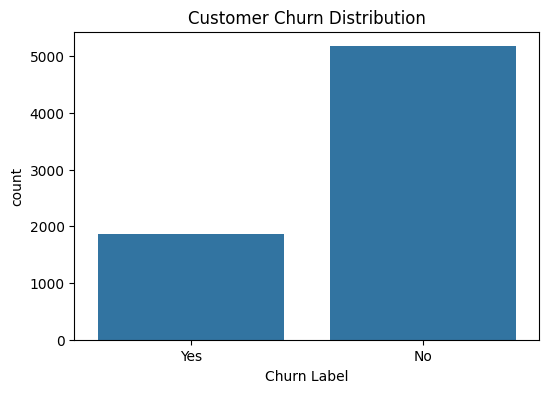

In [34]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn Label',
    data=df
)

plt.title("Customer Churn Distribution")

plt.show()

Churn Percentage

In [35]:
churn_percent = (
    df['Churn Label']
    .value_counts(normalize=True)
    *100
)

print(churn_percent)

Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


Contract Type vs Churn

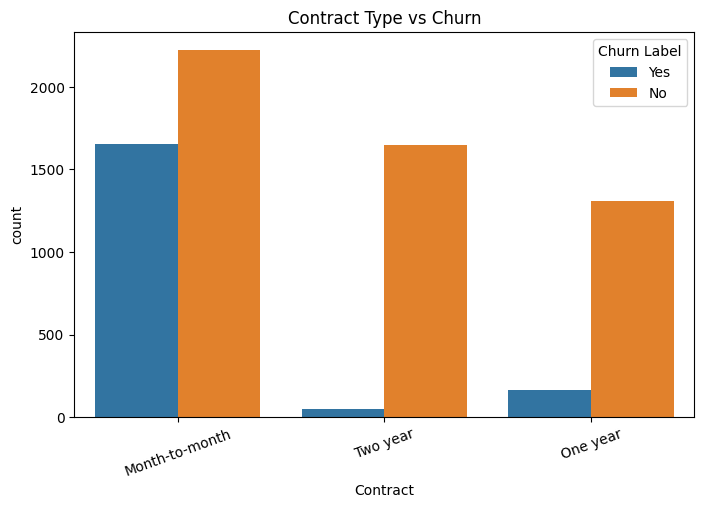

In [36]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Contract',
    hue='Churn Label',
    data=df
)

plt.title("Contract Type vs Churn")

plt.xticks(rotation=20)

plt.show()

Monthly Charges vs Churn

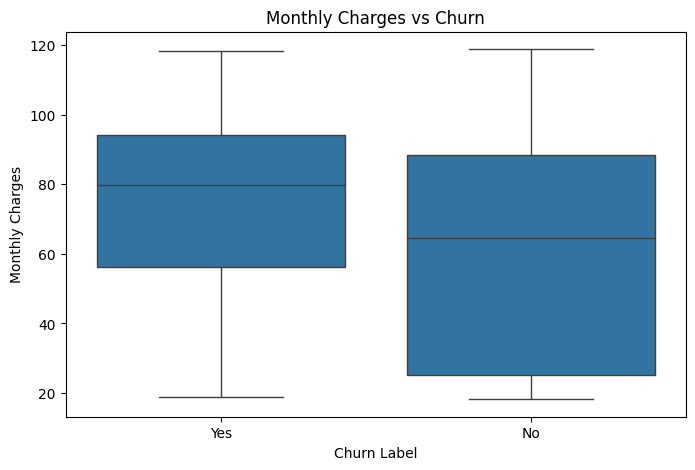

In [37]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn Label',
    y='Monthly Charges',
    data=df
)

plt.title("Monthly Charges vs Churn")

plt.show()

Tenure Analysis

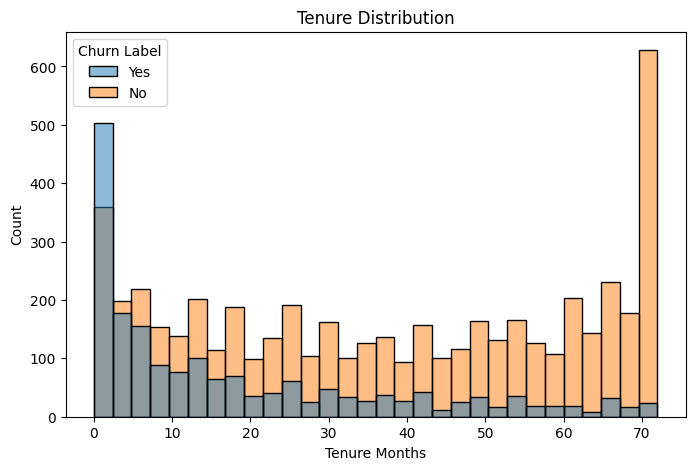

In [38]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='Tenure Months',
    hue='Churn Label',
    bins=30
)

plt.title("Tenure Distribution")

plt.show()

Correlation Heatmap

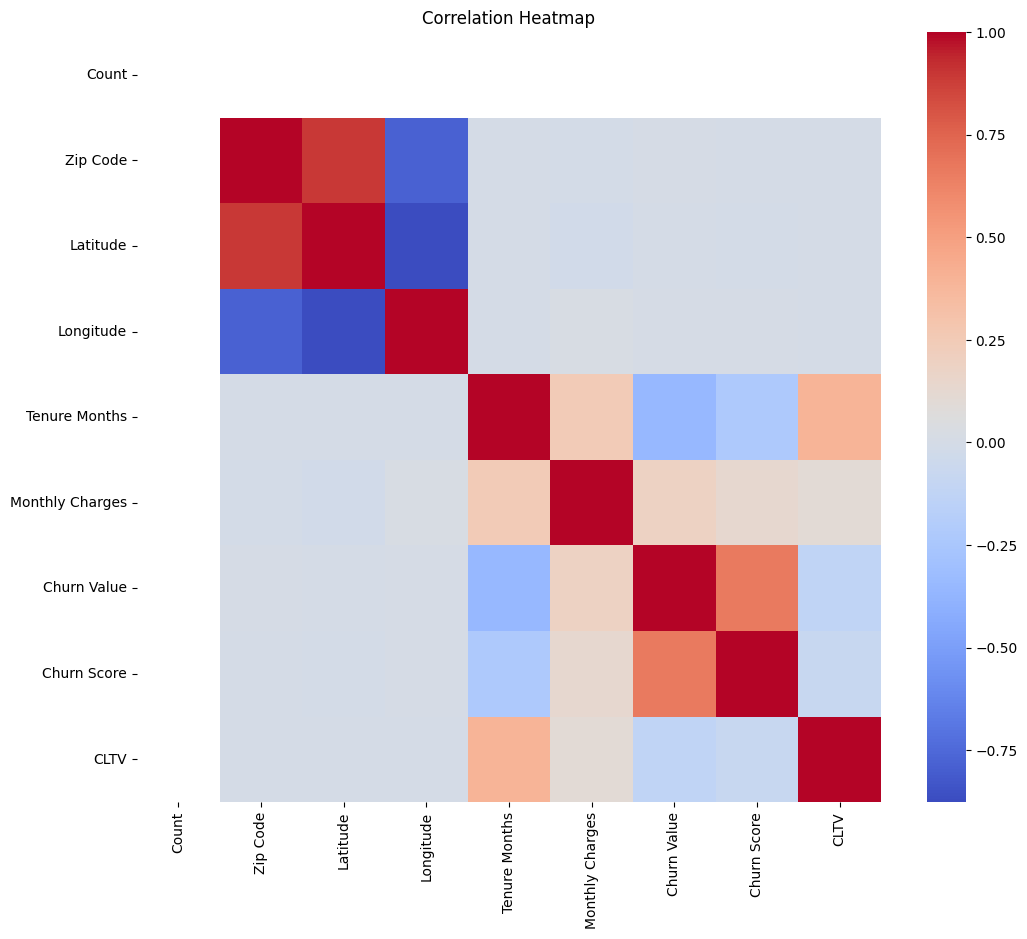

In [39]:
numeric_df = df.select_dtypes(
    include=['int64','float64']
)

plt.figure(figsize=(12,10))

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

Data Cleaning

In [40]:
model_df = df.copy()

leakage_cols = [
    'CustomerID',
    'Lat Long',
    'Churn Score',
    'Churn Value',
    'Churn Reason',
    'Customer Status'
]

for col in leakage_cols:
    if col in model_df.columns:
        model_df.drop(col, axis=1, inplace=True)

Encode Target

In [41]:
model_df['Churn Label'] = model_df[
    'Churn Label'
].map({
    'Yes':1,
    'No':0
})

Encode Categorical Columns

In [42]:
le = LabelEncoder()

for col in model_df.columns:

    if model_df[col].dtype == 'object':

        model_df[col] = le.fit_transform(
            model_df[col].astype(str)
        )

Features and Target

In [43]:
X = model_df.drop(
    'Churn Label',
    axis=1
)

y = model_df['Churn Label']

Step 13: Train-Test Split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Logistic Regression

In [45]:
lr = LogisticRegression(
    max_iter=5000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(
          y_test,
          lr_pred
      ))

Logistic Regression Accuracy: 0.8076650106458482


Random Forest

In [46]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(
          y_test,
          rf_pred
      ))

Random Forest Accuracy: 0.7984386089425124


XGBoost

In [48]:
!pip install xgboost -q

In [49]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(
          y_test,
          xgb_pred
      ))

XGBoost Accuracy: 0.7799858055358411


Model Comparison

In [50]:
results = pd.DataFrame({

    'Model':[
        'Logistic Regression',
        'Random Forest',
        'XGBoost'
    ],

    'Accuracy':[

        accuracy_score(
            y_test,
            lr_pred
        ),

        accuracy_score(
            y_test,
            rf_pred
        ),

        accuracy_score(
            y_test,
            xgb_pred
        )
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.807665
1,Random Forest,0.798439
2,XGBoost,0.779986


Classification Report

In [51]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1035
           1       0.66      0.50      0.57       374

    accuracy                           0.80      1409
   macro avg       0.75      0.70      0.72      1409
weighted avg       0.79      0.80      0.79      1409



Confusion Matrix

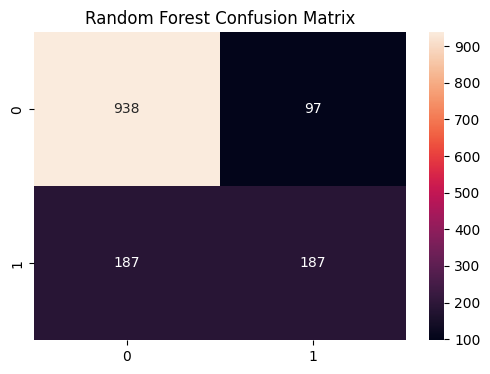

In [52]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Random Forest Confusion Matrix")

plt.show()

ROC Curve

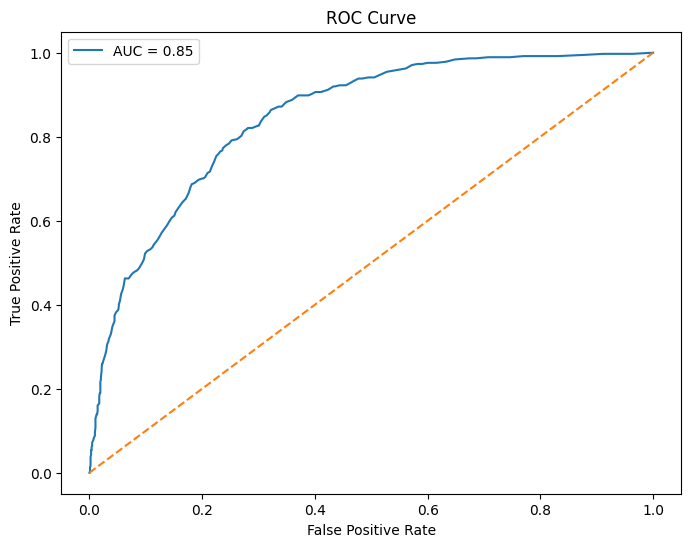

In [53]:
rf_prob = rf.predict_proba(
    X_test
)[:,1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {roc_auc:.2f}'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Feature Importance

In [54]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(
    ascending=False
)

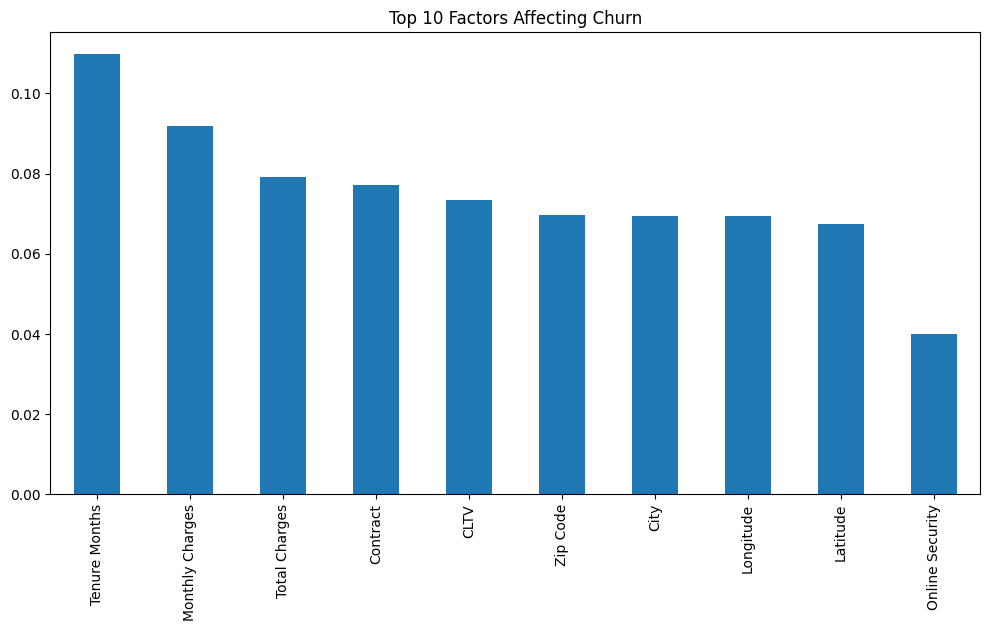

In [55]:
plt.figure(figsize=(12,6))

importance.head(10).plot(
    kind='bar'
)

plt.title(
    "Top 10 Factors Affecting Churn"
)

plt.show()

Save Model

In [56]:
import pickle

pickle.dump(
    rf,
    open(
        "churn_model.pkl",
        "wb"
    )
)

# Business Recommendations

## Key Findings

1. Customers with month-to-month contracts were more likely to churn.

2. Lower tenure customers showed higher churn rates.

3. Monthly charges significantly influenced churn behavior.

4. Service-related attributes played an important role in customer retention.

## Recommendations

- Introduce incentives for long-term contracts.
- Improve onboarding experience for new customers.
- Offer personalized retention campaigns.
- Monitor high-risk customers proactively.